In [1]:
# 1. Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.express as px
sb.set_style('darkgrid')
sb.set_style('whitegrid')

# Preprocessing & Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

# Imbalance Handling
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import BorderlineSMOTE

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('healthcare-dataset-stroke-data.csv')
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
data.drop('id',axis=1,inplace = True)

In [4]:
print(data.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [6]:
# 2. Data Loading & Feature Engineering
df = data.copy()

df['is_elderly'] = (df['age'] > 60).astype(int)

df['high_glucose'] = (df['avg_glucose_level'] > 140).astype(int)

df['is_obese'] = (df['bmi'] > 30).astype(int)

df['risk'] = ((df['age'] > 50) & ((df['hypertension'] == 1) | (df['heart_disease'] == 1))).astype(int)

print("Data shape after Feature Engineering:", df.shape)

Data shape after Feature Engineering: (5110, 15)


In [7]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(
    data,
    title="Stroke Dataset EDA Report",
    explorative=True
)

profile.to_file("eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 19.02it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
profile

##Target distribution

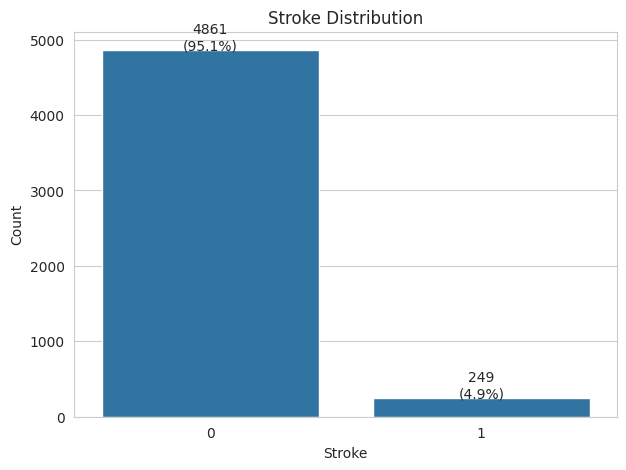

In [9]:
plt.figure(figsize=(7,5))
counts = df['stroke'].value_counts()

sb.barplot(x=counts.index, y=counts.values)
plt.title("Stroke Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")

for i, v in enumerate(counts.values):
    plt.text(i, v, f"{v}\n({v/len(df):.1%})", ha='center')

plt.show()


##Numerical distributions

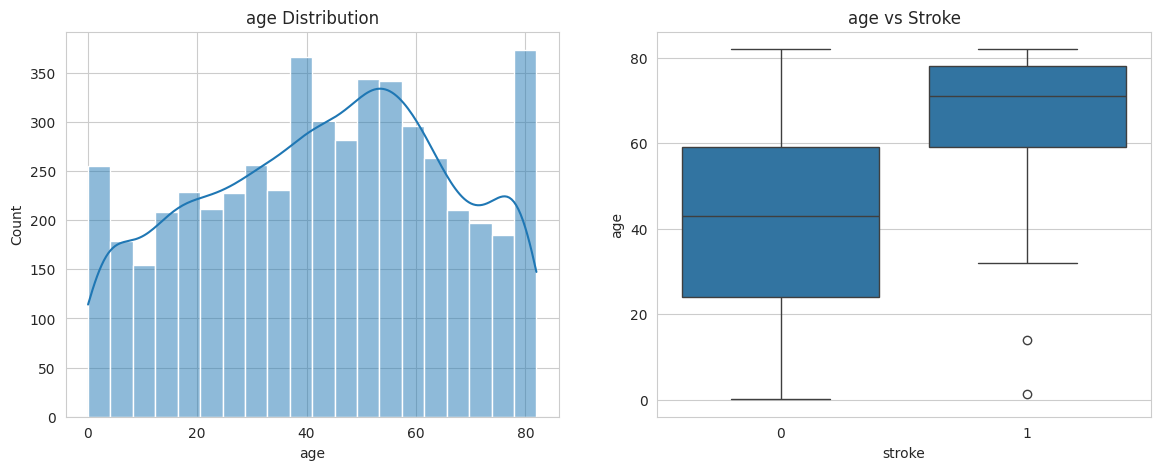

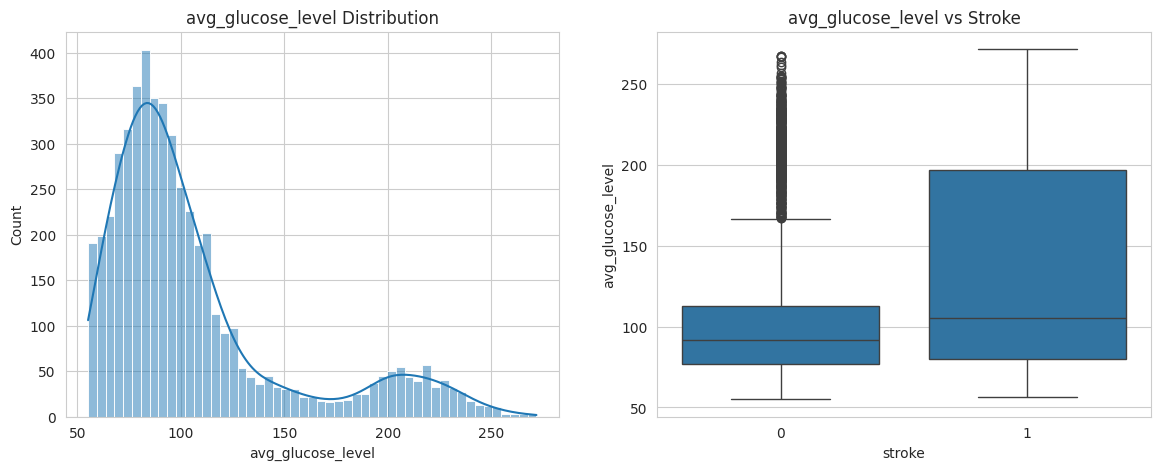

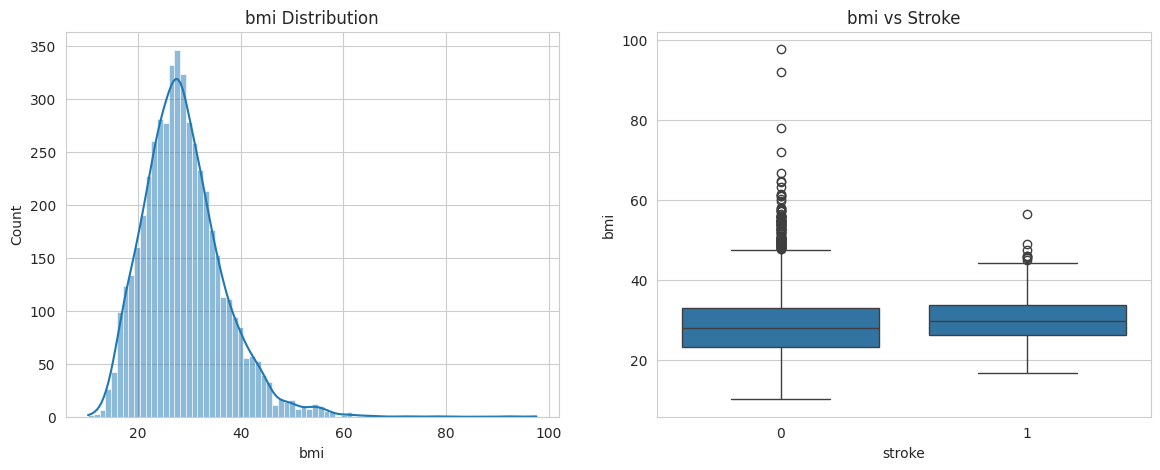

In [10]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

for col in num_cols:
    fig, ax = plt.subplots(1,2, figsize=(14,5))

    # Distribution
    sb.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"{col} Distribution")

    # vs Stroke
    sb.boxplot(x='stroke', y=col, data=df, ax=ax[1])
    ax[1].set_title(f"{col} vs Stroke")

    plt.show()

##Categorical features vs stroke rate

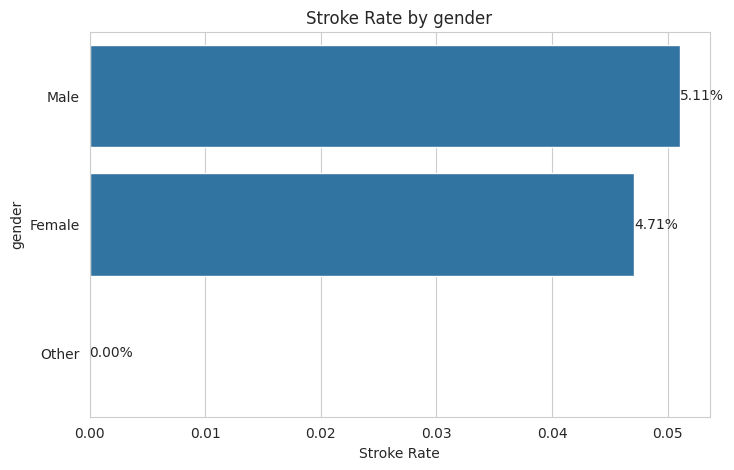

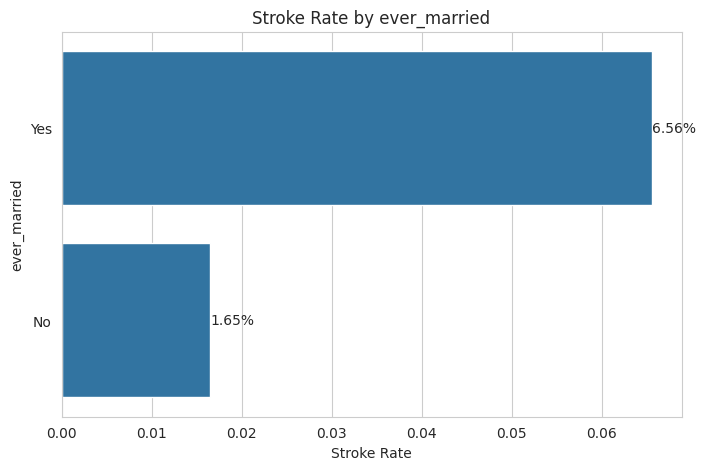

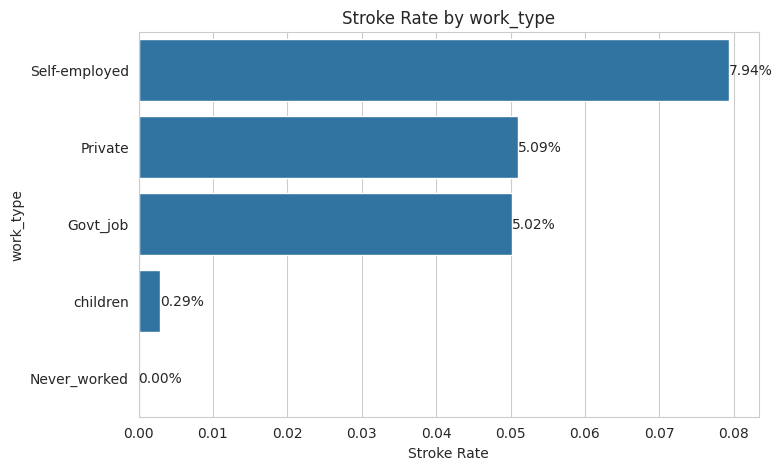

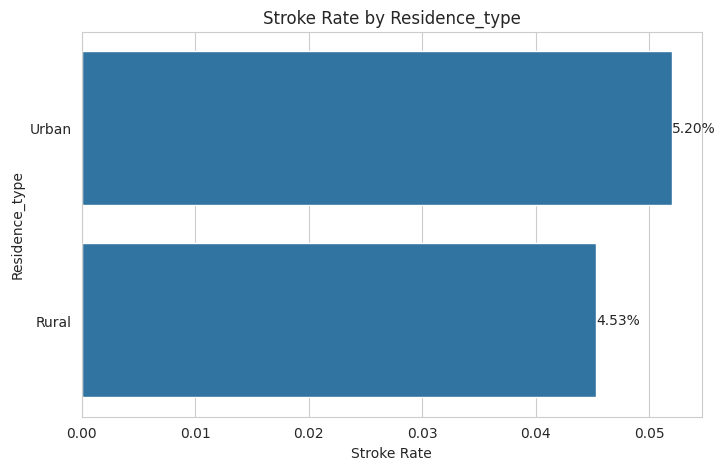

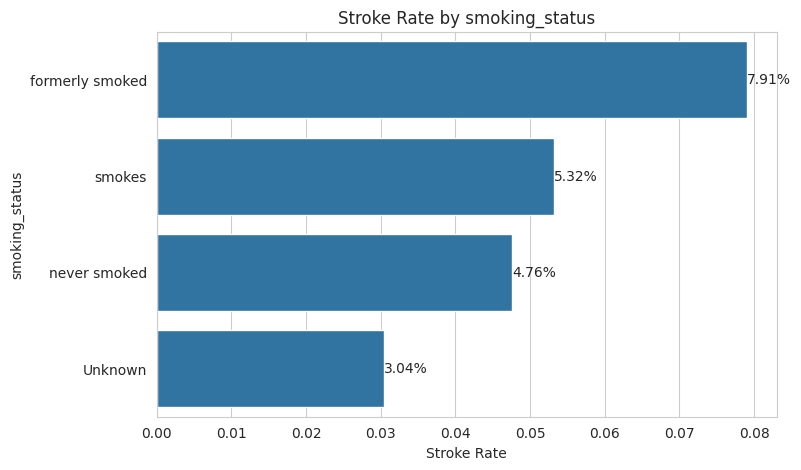

In [11]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in cat_cols:
    plt.figure(figsize=(8,5))

    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)

    sb.barplot(x=stroke_rate.values, y=stroke_rate.index)
    plt.title(f"Stroke Rate by {col}")
    plt.xlabel("Stroke Rate")
    plt.ylabel(col)

    for i, v in enumerate(stroke_rate.values):
        plt.text(v, i, f"{v:.2%}", va='center')

    plt.show()

##Correlation heatmap

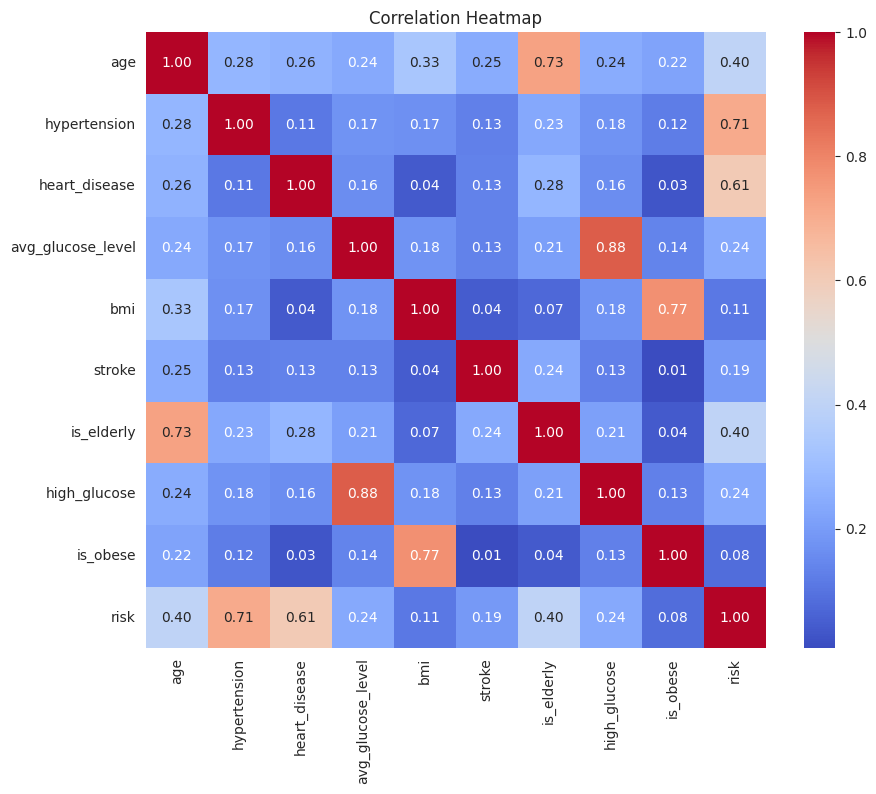

In [12]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sb.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

plt.show()

##Missing values plot

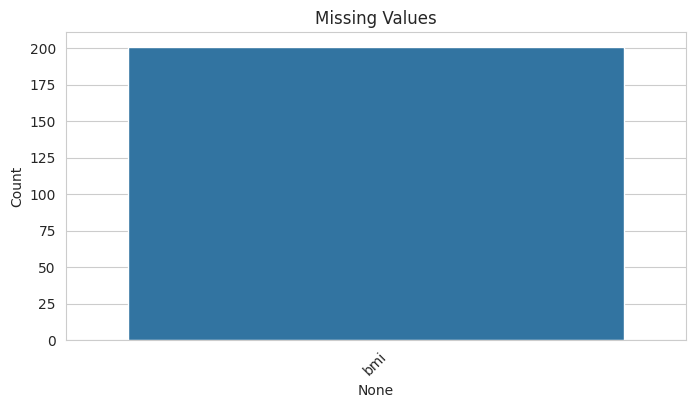

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(8,4))
    sb.barplot(x=missing.index, y=missing.values)
    plt.title("Missing Values")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("No Missing Values ✅")

In [14]:
print("\nSkewness:\n")
print(df[num_cols].skew())


Skewness:

age                 -0.137059
avg_glucose_level    1.572284
bmi                  1.055340
dtype: float64


## Does stroke depend upon gender?

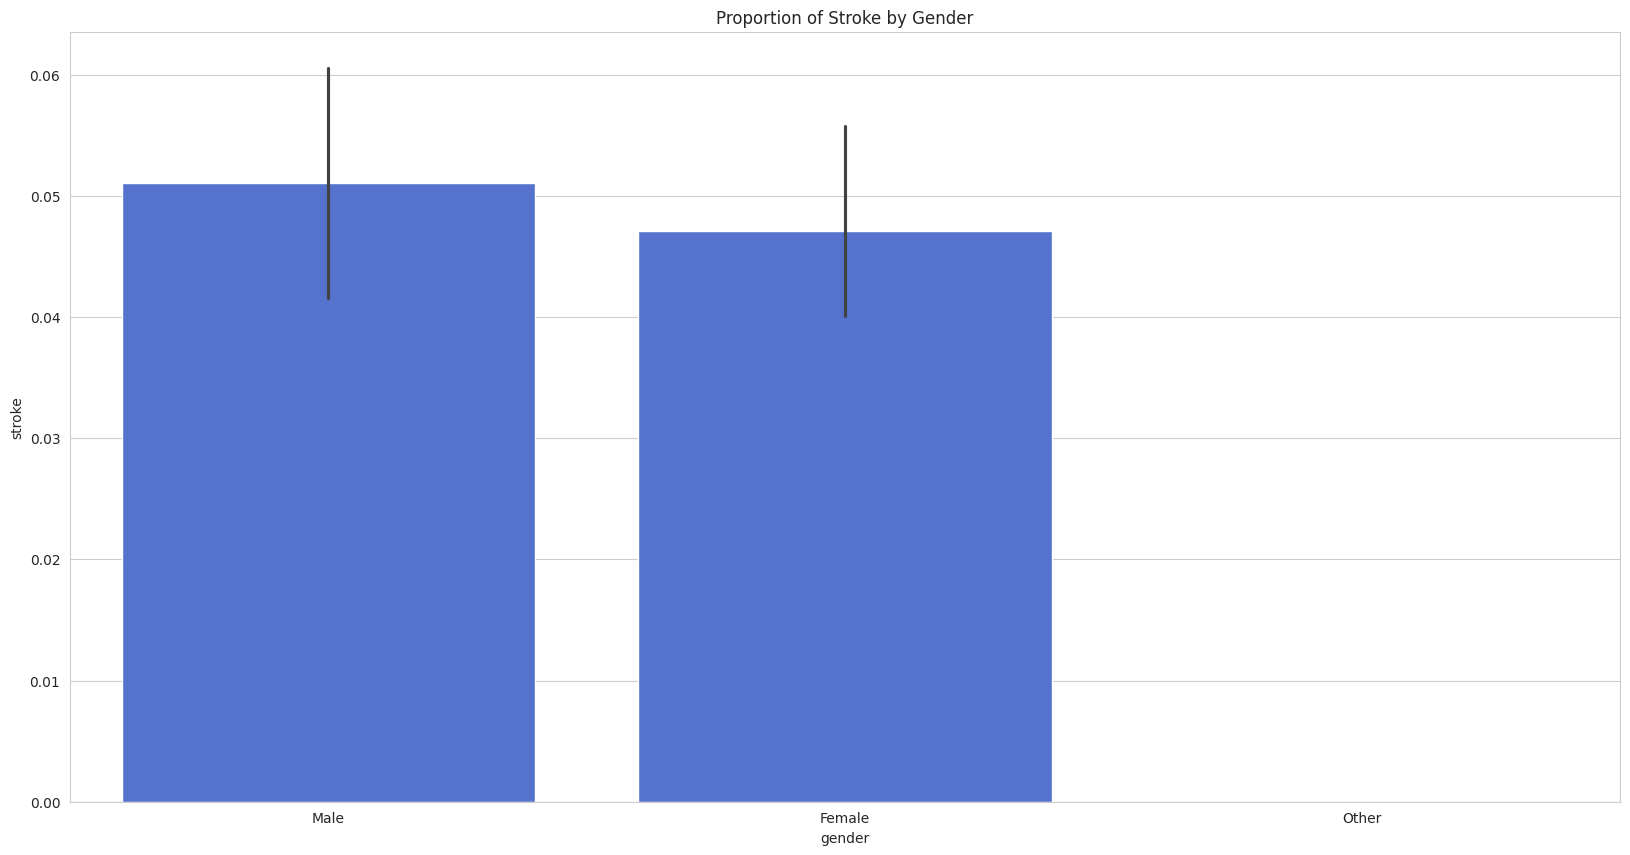

In [15]:
plt.figure(figsize=(20,10))
sb.barplot(x=df['gender'], y=df['stroke'], color = 'royalblue')
plt.title("Proportion of Stroke by Gender")
plt.show()

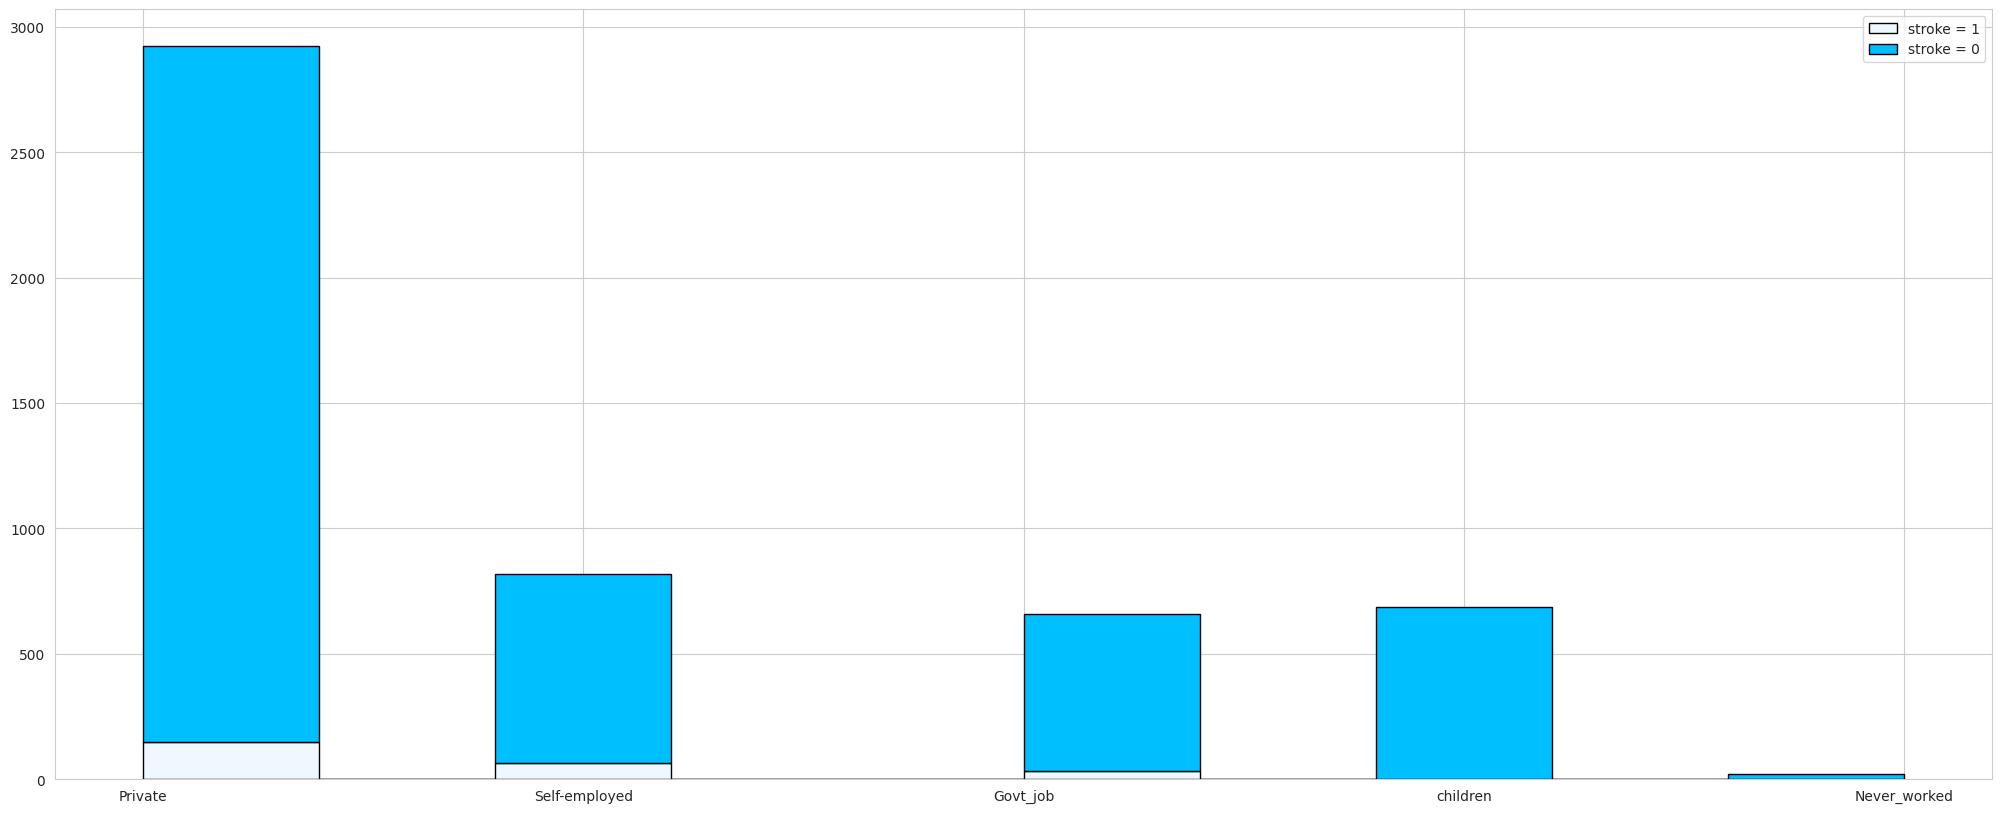

In [16]:
plt.figure(figsize = (25,10))
plt.hist(x = [data[data['stroke']==1]['work_type'],data[data['stroke']==0]['work_type']],stacked = True,edgecolor = 'black',color = ['aliceblue','deepskyblue'],label = ['stroke = 1','stroke = 0'])
plt.legend()
plt.show()

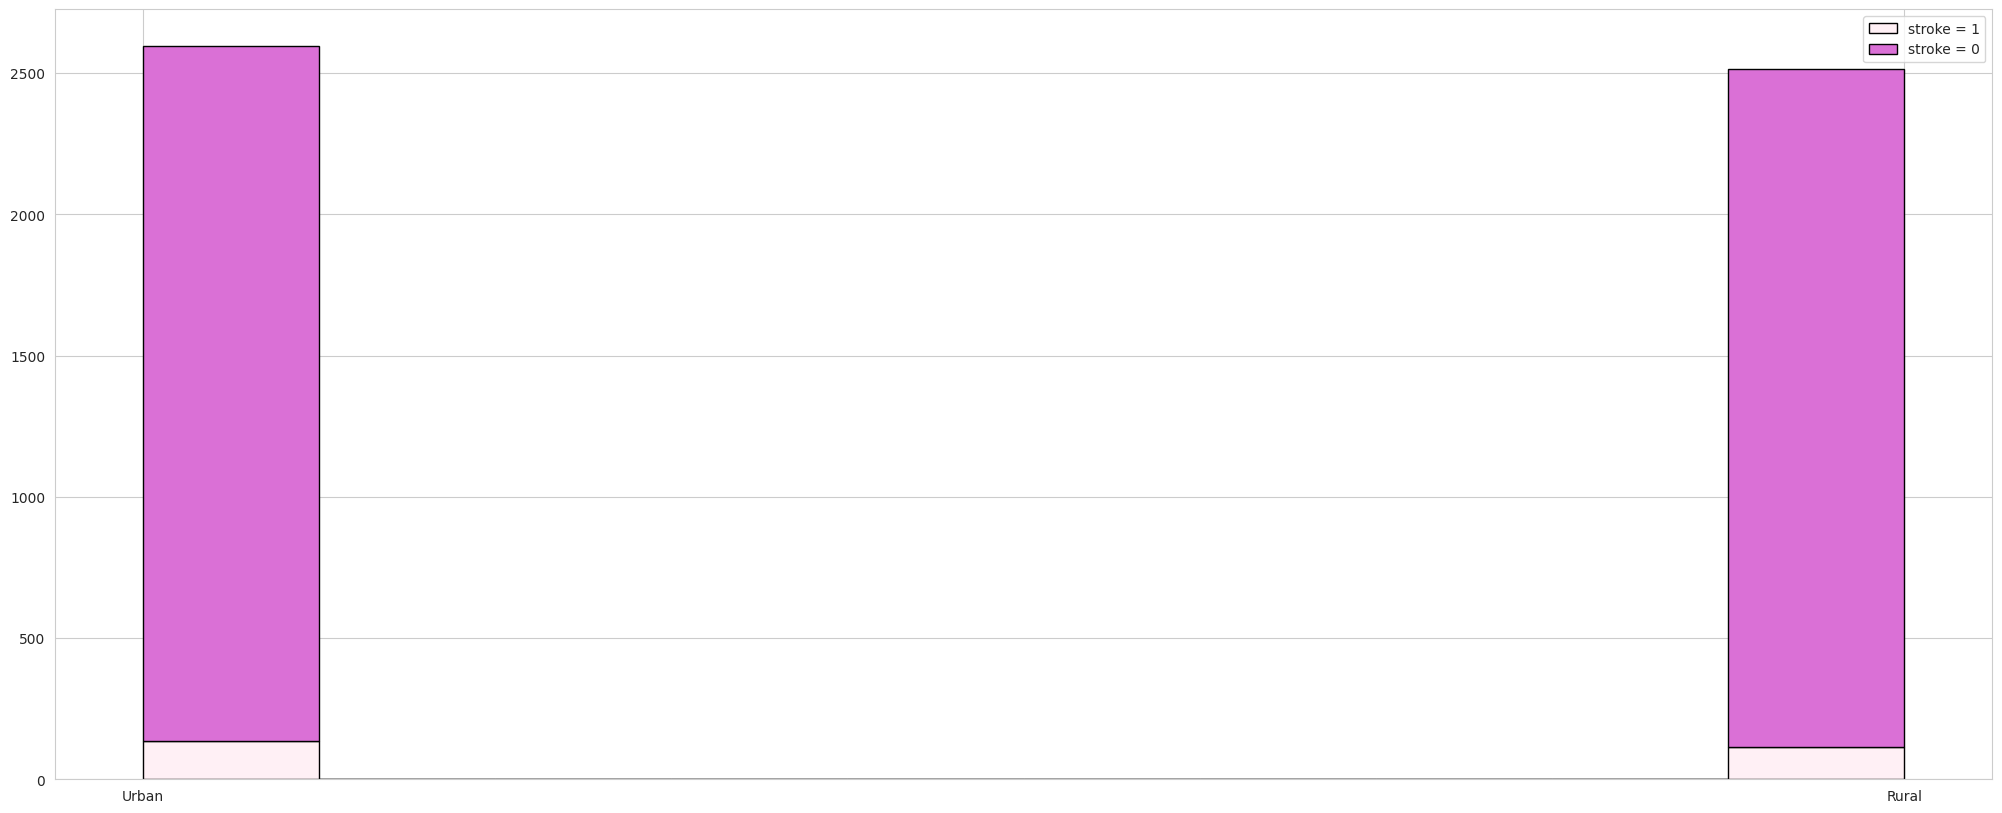

In [17]:
plt.figure(figsize = (25,10))
plt.hist(x = [data[data['stroke']==1]['Residence_type'],data[data['stroke']==0]['Residence_type']],stacked = True,edgecolor = 'black',color = ['lavenderblush','orchid'],label = ['stroke = 1','stroke = 0'])
plt.legend()
plt.show()

## L.Does average glucose level afffet chances of stroke?

Text(0.5, 1.0, 'Average Glucose level')

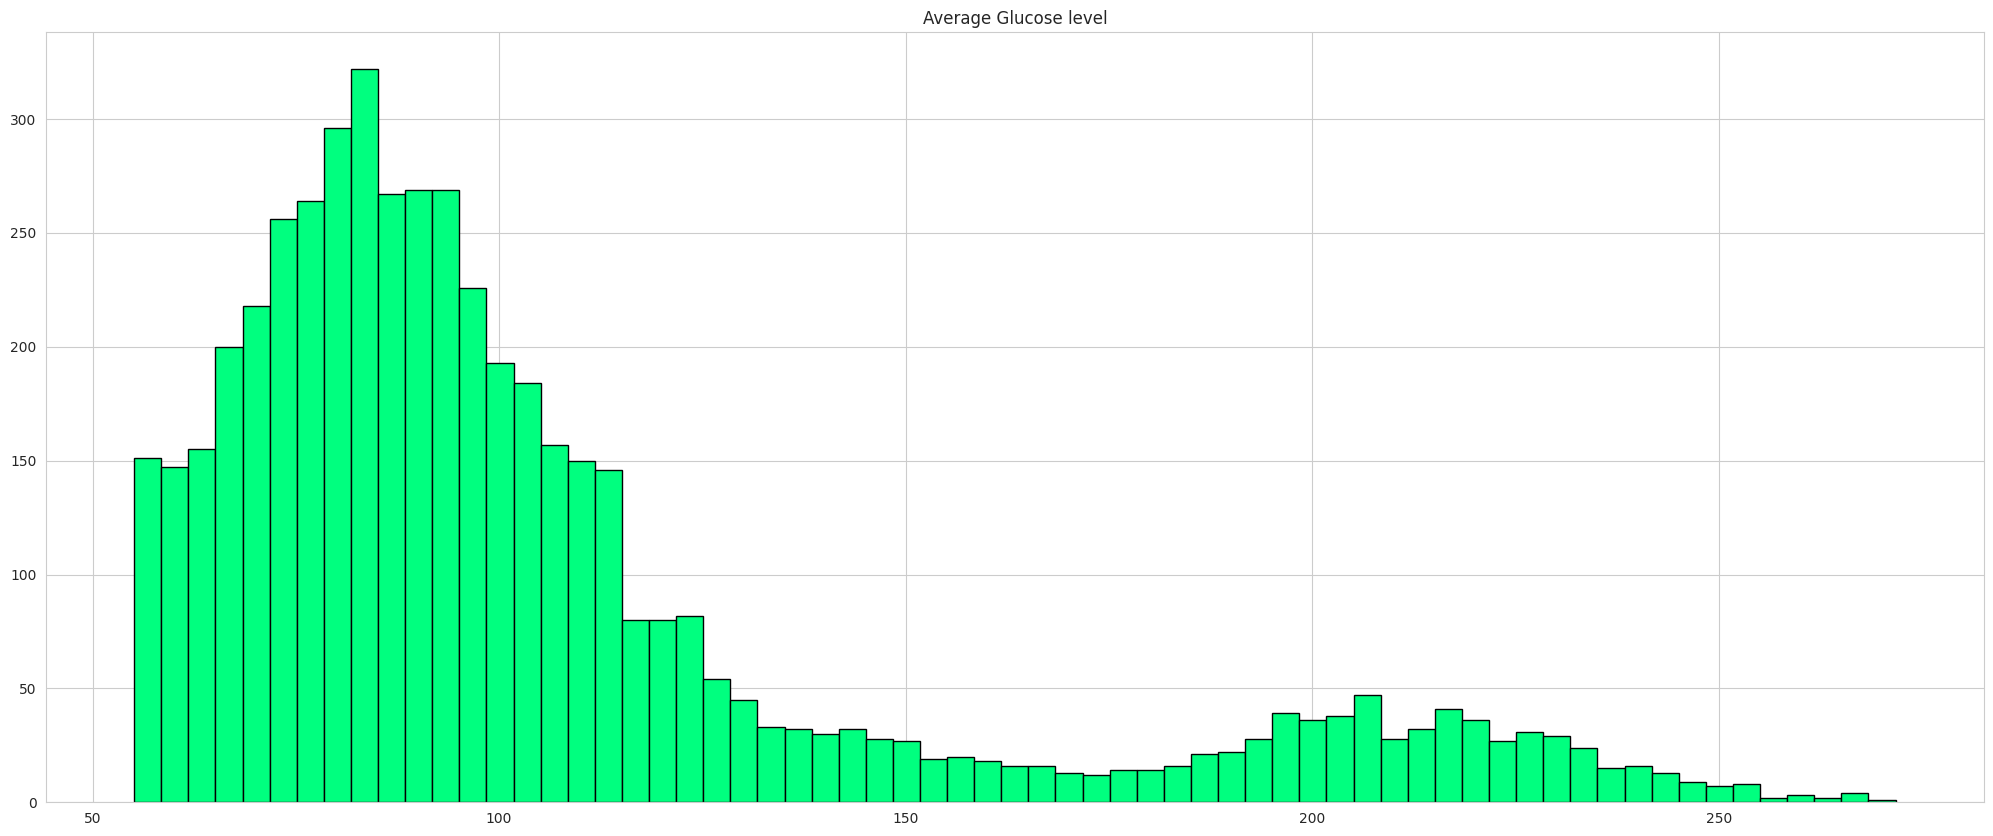

In [18]:
plt.figure(figsize=(25,10))
plt.hist(data['avg_glucose_level'],bins = 65,edgecolor = 'black',color = 'springgreen');
plt.title("Average Glucose level")

## M. Does BMI affect stroke

Text(0.5, 1.0, 'BMI spread')

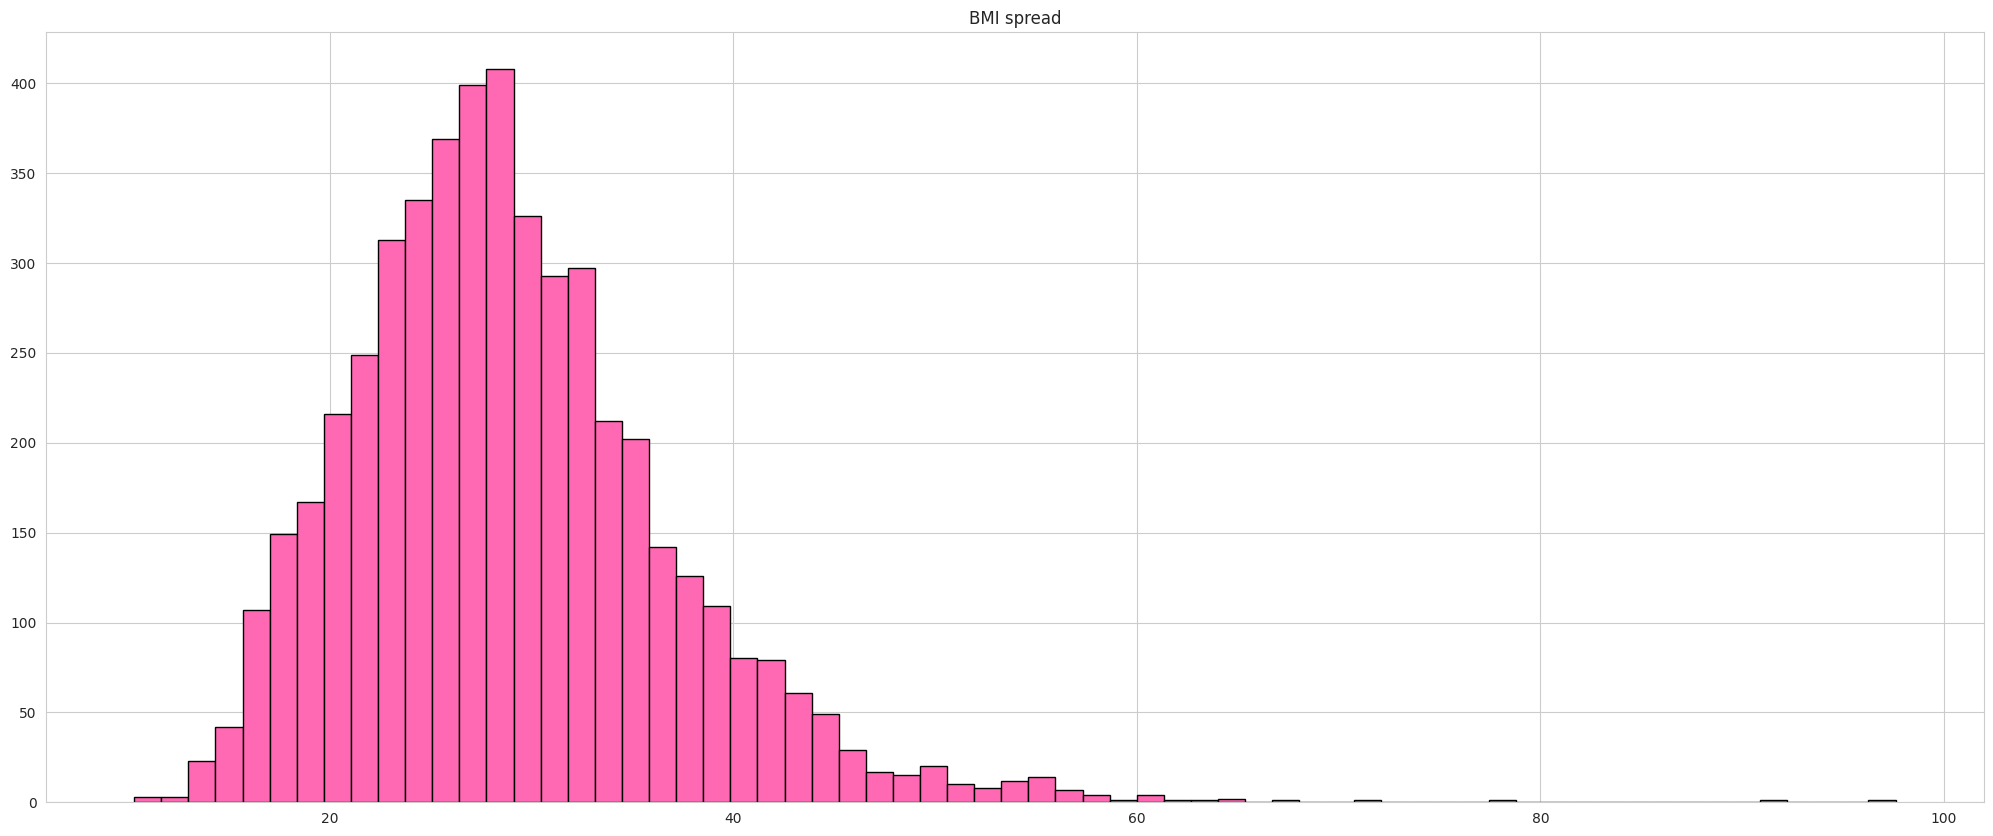

In [19]:
plt.figure(figsize=(25,10))
plt.hist(data['bmi'],bins = 65,edgecolor = 'black',color = 'hotpink');
plt.title("BMI spread")

## N. How does smoking affect stroke?

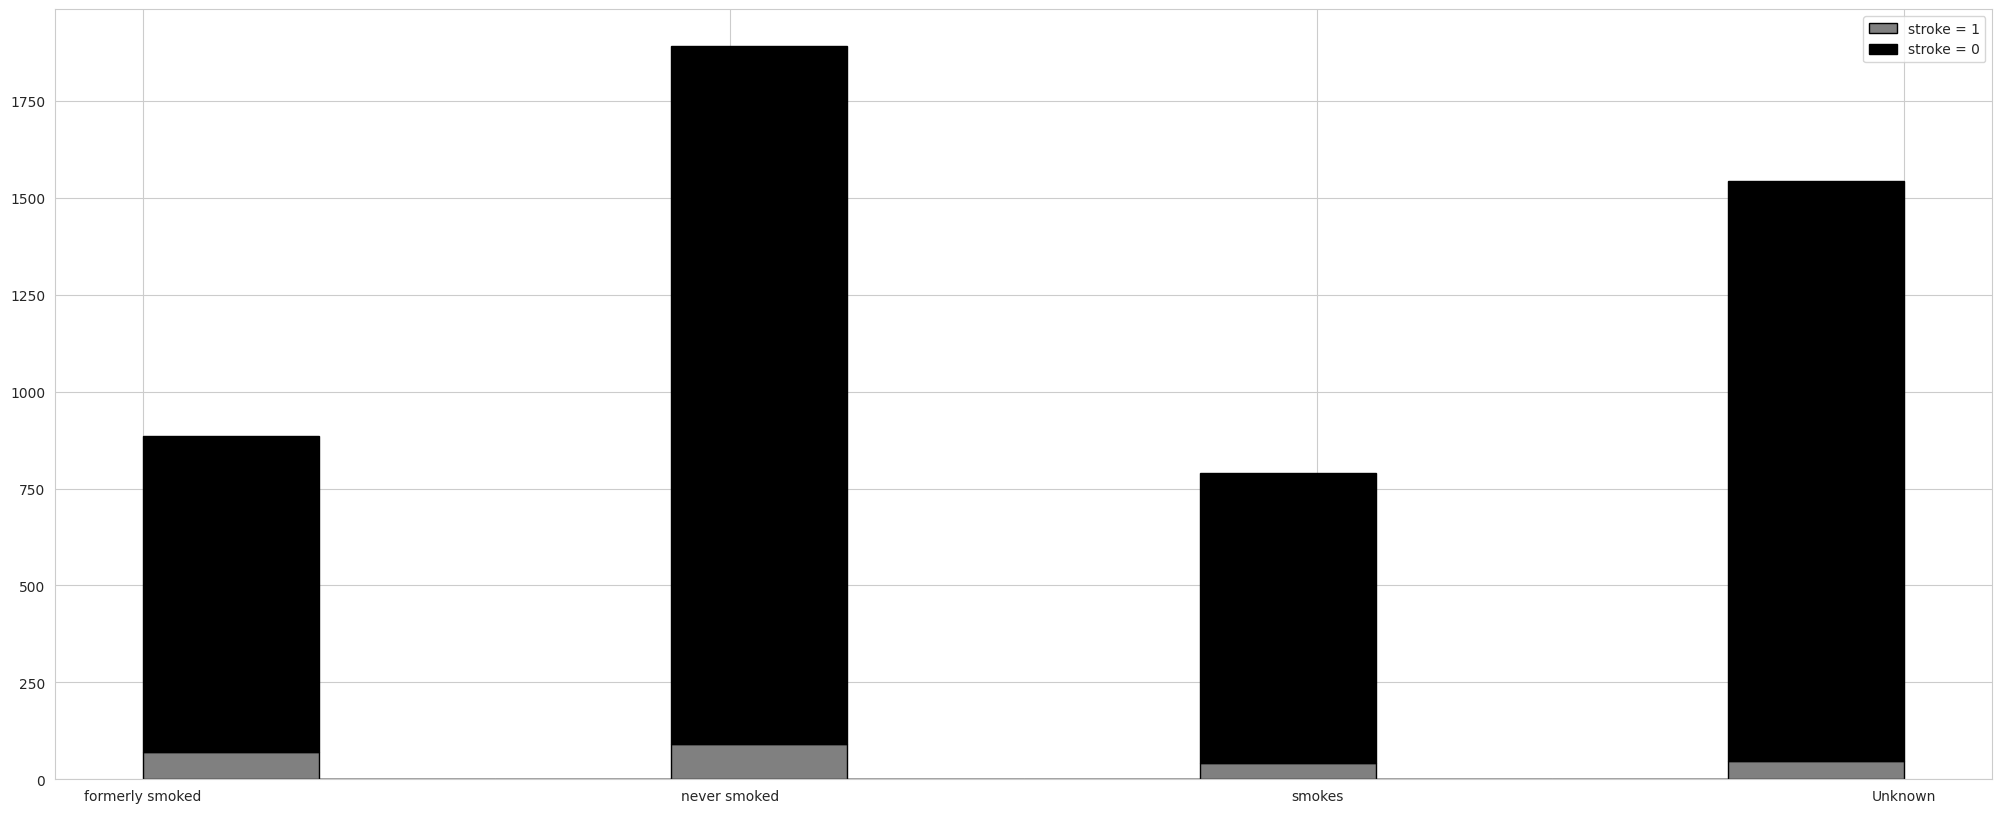

In [20]:
plt.figure(figsize = (25,10))
plt.hist(x = [data[data['stroke']==1]['smoking_status'],data[data['stroke']==0]['smoking_status']],stacked = True,edgecolor = 'black',color = ['gray','black'],label = ['stroke = 1','stroke = 0'])
plt.legend()
plt.show()

In [21]:
# 3. Data Splitting (Preventing Data Leakage)
X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training cases: {X_train.shape[0]}, Testing cases: {X_test.shape[0]}")

Training cases: 4088, Testing cases: 1022


In [22]:
# 4. Building Preprocessing Pipelines
num_cols = ['age', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
passthrough_cols = ['hypertension', 'heart_disease', 'is_elderly', 'high_glucose', 'is_obese','risk']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
        ('pass', 'passthrough', passthrough_cols)
    ])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [23]:
# 5. Handling Imbalanced Data
bsmote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_res, y_train_res = bsmote.fit_resample(X_train_proc, y_train)

print(f"Before SMOTE - Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}")
print(f"After SMOTE  - Class 0: {sum(y_train_res==0)}, Class 1: {sum(y_train_res==1)}")

Before SMOTE - Class 0: 3889, Class 1: 199
After SMOTE  - Class 0: 3889, Class 1: 3889


In [24]:
# 6. Building the Master Ensemble Model
lgbm = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.03, min_child_samples=20, random_state=42)

xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')

rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=4, random_state=42)

ensemble = VotingClassifier(estimators=[
    ('lgbm', lgbm),
    ('xgb', xgb),
    ('rf', rf)
], voting='soft')

calibrated_ensemble = CalibratedClassifierCV(estimator=ensemble, method='isotonic', cv=3)
calibrated_ensemble.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 2593, number of negative: 2592
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3551
[LightGBM] [Info] Number of data points in the train set: 5185, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500096 -> initscore=0.000386
[LightGBM] [Info] Start training from score 0.000386
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

CalibratedClassifierCV(cv=3,
                       estimator=VotingClassifier(estimators=[('lgbm',
                                                               LGBMClassifier(learning_rate=0.03,
                                                                              max_depth=6,
                                                                              n_estimators=200,
                                                                              random_state=42)),
                                                              ('xgb',
                                                               XGBClassifier(base_score=None,
                                                                             booster=None,
                                                                             callbacks=None,
                                                                             colsample_bylevel=None,
                                                                             colsample_bynode=None,
                                                                             colsample_bytree=0.8,
                                                                             device=None,
                                                                             early_stopping_rounds=None,
                                                                             enable_categorical=False...
                                                                             max_cat_threshold=None,
                                                                             max_cat_to_onehot=None,
                                                                             max_delta_step=None,
                                                                             max_depth=5,
                                                                             max_leaves=None,
                                                                             min_child_weight=None,
                                                                             missing=nan,
                                                                             monotone_constraints=None,
                                                                             multi_strategy=None,
                                                                             n_estimators=200,
                                                                             n_jobs=None,
                                                                             num_parallel_tree=None, ...)),
                                                              ('rf',
                                                               RandomForestClassifier(max_depth=8,
                                                                                      min_samples_leaf=4,
                                                                                      n_estimators=300,
                                                                                      random_state=42))],
                                                  voting='soft'),
                       method='isotonic')

--- Final Model Performance ---

Confusion Matrix:


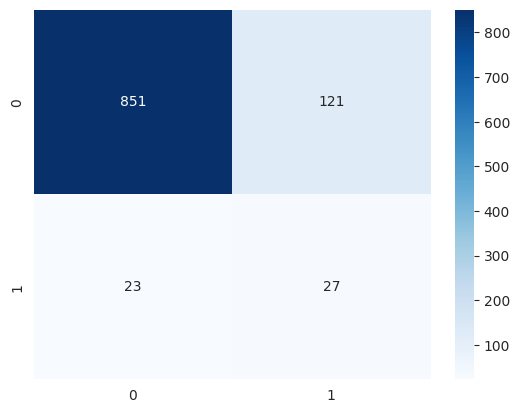


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       972
           1       0.18      0.54      0.27        50

    accuracy                           0.86      1022
   macro avg       0.58      0.71      0.60      1022
weighted avg       0.93      0.86      0.89      1022


ROC-AUC Score: 0.8232


In [25]:
# 7. Model Evaluation
y_prob = calibrated_ensemble.predict_proba(X_test_proc)[:, 1]

threshold = 0.06
y_pred = (y_prob >= threshold).astype(int)

print("--- Final Model Performance ---")
print("\nConfusion Matrix:")
sb.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

In [26]:
# 8. Saving Models in a Single Bundle for Backend
import joblib

stroke_bundle = {
    'preprocessor': preprocessor,
    'model': calibrated_ensemble,
    'threshold': threshold
}

joblib.dump(stroke_bundle, 'stroke_bundle.pkl')

['stroke_bundle.pkl']